# Cell 1
## -> Checking PyTorch and GPU

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# This is the PyTorch equivalent of checking tf.config.list_physical_devices("GPU")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

PyTorch version: 2.11.0+cu128
GPU available: True
Device name: Tesla T4

Using device: cuda


# Cell 2
## Loading MNIST using torchvision

In [ ]:

# Define transforms - equivalent to keras`s rescale=1./255
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST-specific mean/std normalization
])

# Download and load training data
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: P{len(test_dataset)}")
print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

images, labels = next(iter(train_loader))
print(f"\nBatch image shape: {images.shape}")
print(f"Image dtype: {images.dtype}")
print(f"Label range: {labels.min()} to {labels.max()}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 52.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.79MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.1MB/s]

Training samples: 60000
Test samples: P10000
Training batches: 938
Test batches: 157



Batch image shape: torch.Size([64, 1, 28, 28])
Image dtype: torch.float32
Label range: 0 to 9


# Cell 3
## -> Visualize sample images

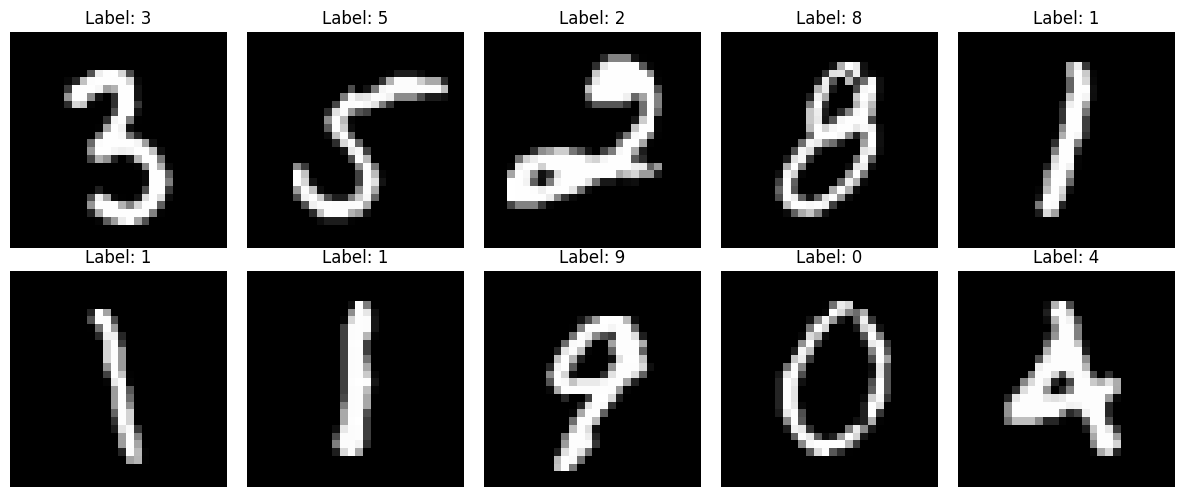

In [ ]:
# Unnormalize for display
def show_images(images, labels, n=10):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    axes = axes.flatten()
    for i in range(n):
        # Reverse normalization for display
        img = images[i].squeeze().numpy()   # remove channel dim: (1,28,28) → (28,28)
        img = img * 0.3081 + 0.1307         # reverse Normalize
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Label: {labels[i].item()}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

images, labels = next(iter(train_loader))
show_images(images, labels)

# Cell 4
## Define the CNN model(the bigest diffrence from keras)

In [ ]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.25)

        # Block 2
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.25)

        # Classifier head
        self.fc1   = nn.Linear(64 * 7 * 7, 256)
        self.bn5   = nn.BatchNorm1d(256)
        self.drop3 = nn.Dropout(0.5)
        self.fc2   = nn.Linear(256, 10)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.drop1(x)

        # Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.drop2(x)

        # Flatten — PyTorch equivalent of Keras's Flatten()
        x = x.view(x.size(0), -1)   # (batch, 64, 7, 7) → (batch, 3136)

        # Classifier
        x = F.relu(self.bn5(self.fc1(x)))
        x = self.drop3(x)
        x = self.fc2(x)   # raw logits — no softmax here

        return x

model = MNISTClassifier().to(device)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

MNISTClassifier(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=256, bias=True)
 

# Cell 5
## Define loss, optimizer & write the training loop

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()   # sets dropout and batchnorm to training mode
    running_loss = 0.0
    correct      = 0
    total        = 0

    for images, labels in loader:
        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Zero gradients — MUST do this every batch in PyTorch
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass — calculate gradients
        loss.backward()

        # Update weights
        optimizer.step()

        # Track metrics
        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    model.eval()    # sets dropout and batchnorm to evaluation mode
    running_loss = 0.0
    correct      = 0
    total        = 0

    with torch.no_grad():   # disable gradient computation for speed
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted  = torch.max(outputs, 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

print("Training and evaluation functions defined!")

Training and evaluation functions defined!


# Cell 6
## Run the full training loop

In [ ]:
EPOCHS = 15
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader,
                                         optimizer, criterion, device)

    # Evaluate
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/best_mnist_model.pth')

    # Log
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print(f"\nBest validation accuracy: {best_val_acc:.2f}%")

Epoch  1/15 | Train Loss: 0.1290 | Train Acc: 96.47% | Val Loss: 0.0342 | Val Acc: 98.88%
Epoch  2/15 | Train Loss: 0.0511 | Train Acc: 98.43% | Val Loss: 0.0237 | Val Acc: 99.26%
Epoch  3/15 | Train Loss: 0.0430 | Train Acc: 98.64% | Val Loss: 0.0237 | Val Acc: 99.19%
Epoch  4/15 | Train Loss: 0.0364 | Train Acc: 98.92% | Val Loss: 0.0162 | Val Acc: 99.47%
Epoch  5/15 | Train Loss: 0.0315 | Train Acc: 99.00% | Val Loss: 0.0184 | Val Acc: 99.37%
Epoch  6/15 | Train Loss: 0.0296 | Train Acc: 99.07% | Val Loss: 0.0181 | Val Acc: 99.42%
Epoch  7/15 | Train Loss: 0.0266 | Train Acc: 99.17% | Val Loss: 0.0161 | Val Acc: 99.40%
Epoch  8/15 | Train Loss: 0.0243 | Train Acc: 99.22% | Val Loss: 0.0181 | Val Acc: 99.32%
Epoch  9/15 | Train Loss: 0.0214 | Train Acc: 99.32% | Val Loss: 0.0173 | Val Acc: 99.46%
Epoch 10/15 | Train Loss: 0.0206 | Train Acc: 99.35% | Val Loss: 0.0143 | Val Acc: 99.55%
Epoch 11/15 | Train Loss: 0.0213 | Train Acc: 99.32% | Val Loss: 0.0135 | Val Acc: 99.53%
Epoch 12/1

# Cell 7
## Plot results & final evaluation

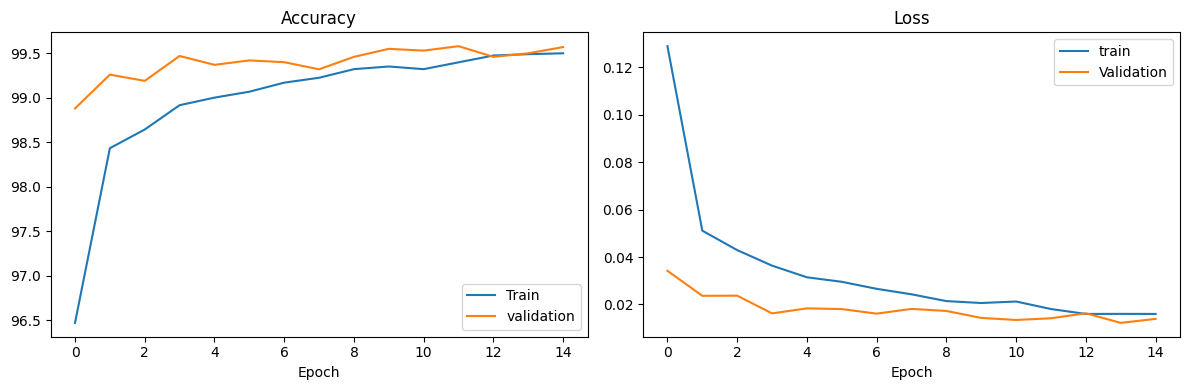

Final test accuracy: 99.58%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_acc'], label='Train')
ax1.plot(history['val_acc'], label='validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['train_loss'], label='train')
ax2.plot(history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/pytorch_mnist_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Load best weights and get final test accuracy
model.load_state_dict(torch.load('/content/best_mnist_model.pth'))
final_loss, final_acc = evaluate(model, test_loader, criterion, device)
print(f"Final test accuracy: {final_acc:.2f}%")
